In [1]:
import pandas as pd, numpy as np
from paths import OUT_DIR

df = pd.read_csv(OUT_DIR / "prices_ForGAN_c9.csv")
df["mny_bin"] = pd.cut(df.moneyness, [0.5, 0.8, 0.95, 1.05, 1.2, 1.5, 2.0])
print(df.groupby("mny_bin", observed=True).agg(
    n=("implied_vol", "size"),
    inverted=("implied_vol", lambda s: s.notna().sum()),
    mean_price=("price", "mean"),
    mean_mkt_iv=("market_iv", "mean"),
))

                n  inverted  mean_price  mean_mkt_iv
mny_bin                                             
(0.5, 0.8]    275       245   13.853922     0.748237
(0.8, 0.95]   142       142    5.581070     0.607670
(0.95, 1.05]   98        98    2.289042     0.580448
(1.05, 1.2]   139       139    0.732295     0.647342
(1.2, 1.5]    230       175    0.082619     0.766860
(1.5, 2.0]    337        32    0.002098     0.896677


In [2]:
import pandas as pd, numpy as np
from paths import OUT_DIR

df = pd.read_csv(OUT_DIR / "prices_ForGAN_c9.csv", parse_dates=["valuation"])
df["mny_bin"] = pd.cut(df.moneyness, [0.5, 0.8, 0.95, 1.05, 1.2, 1.5, 2.0])

print(df.groupby("mny_bin", observed=True).agg(
    n           = ("implied_vol", "size"),
    inverted    = ("implied_vol", lambda s: s.notna().sum()),
    model_iv    = ("implied_vol", "mean"),
    market_iv   = ("market_iv", "mean"),
).round(3))

                 n  inverted  model_iv  market_iv
mny_bin                                          
(0.5, 0.8]    1375       973     0.504      0.748
(0.8, 0.95]    710       700     0.395      0.608
(0.95, 1.05]   490       490     0.366      0.580
(1.05, 1.2]    695       695     0.383      0.647
(1.2, 1.5]    1150       991     0.485      0.767
(1.5, 2.0]    1685       799     0.801      0.897


In [3]:
import pandas as pd, numpy as np
from paths import OUT_DIR

df = pd.read_csv(OUT_DIR / "prices_ForGAN_c9.csv", parse_dates=["valuation"])
d = df[df.valuation == "2026-02-26"]

print(f"F_t = {d.F_t.iloc[0]:.2f}   T = {d['T'].iloc[0]:.4f}")
print(f"strikes {d.strike.nunique()}   seeds {d.seed.nunique()}\n")

pivot = d.pivot_table(index=["strike", "moneyness", "market_iv"],
                      columns="seed", values="implied_vol").reset_index()
pivot.columns.name = None
pivot["model_mean"] = pivot[[0,1,2,3,4]].mean(axis=1)
pivot["model_sd"]   = pivot[[0,1,2,3,4]].std(axis=1)

print(pivot[["moneyness","market_iv","model_mean","model_sd"]]
      .round(3).to_string(index=False))

F_t = 32.22   T = 0.0794
strikes 59   seeds 5

 moneyness  market_iv  model_mean  model_sd
     0.528      0.963       0.517     0.197
     0.559      0.901       0.507     0.209
     0.590      0.846       0.562     0.101
     0.621      0.799       0.574     0.068
     0.636      0.780       0.568     0.067
     0.652      0.763       0.562     0.067
     0.667      0.750       0.555     0.069
     0.683      0.739       0.500     0.114
     0.698      0.731       0.493     0.114
     0.714      0.726       0.486     0.118
     0.729      0.724       0.479     0.121
     0.745      0.725       0.472     0.124
     0.760      0.729       0.464     0.129
     0.776      0.734       0.414     0.152
     0.791      0.742       0.407     0.154
     0.807      0.752       0.402     0.156
     0.822      0.763       0.395     0.158
     0.838      0.775       0.389     0.161
     0.853      0.789       0.382     0.162
     0.857      0.792       0.381     0.162
     0.869      0.803       0

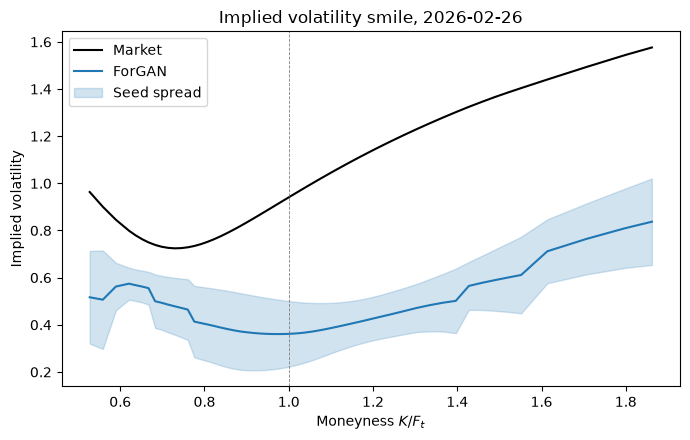

In [4]:
"""
Plot the model smile against the market smile for one valuation date.
"""

import matplotlib.pyplot as plt
import pandas as pd

from paths import OUT_DIR

DATE = "2026-02-26"

df = pd.read_csv(OUT_DIR / "prices_ForGAN_c9.csv", parse_dates=["valuation"])
d = df[df.valuation == DATE]

piv = d.pivot_table(index=["moneyness", "market_iv"],
                    columns="seed", values="implied_vol").reset_index()
piv.columns.name = None
seeds = [c for c in piv.columns if isinstance(c, (int, float)) and c in [0,1,2,3,4]]

piv["mean"] = piv[seeds].mean(axis=1)
piv["sd"]   = piv[seeds].std(axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(piv.moneyness, piv.market_iv, color="black", lw=1.5, label="Market")
ax.plot(piv.moneyness, piv["mean"], color="tab:blue", lw=1.5, label="ForGAN")
ax.fill_between(piv.moneyness, piv["mean"] - piv["sd"], piv["mean"] + piv["sd"],
                color="tab:blue", alpha=0.2, label="Seed spread")

ax.axvline(1.0, color="grey", lw=0.6, ls="--")
ax.set_xlabel(r"Moneyness $K/F_t$")
ax.set_ylabel("Implied volatility")
ax.set_title(f"Implied volatility smile, {DATE}")
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
import pandas as pd
from paths import RUNS

df = pd.read_csv(RUNS / "results_c9.csv")

stats = ["pool_std", "pool_skew", "pool_kurt", "pool_min", "pool_max",
         "pool_q01", "pool_q99", "pool_frac_abs_gt_0.05", "pool_frac_abs_gt_0.1",
         "path_acf2_lag1", "path_acf2_lag2", "path_acf2_lag5", "path_acf2_lag10"]

g = df.groupby("loss")[stats].agg(["mean", "std"])
print(g.round(4).to_string())

            pool_std         pool_skew         pool_kurt         pool_min         pool_max         pool_q01         pool_q99         pool_frac_abs_gt_0.05         pool_frac_abs_gt_0.1         path_acf2_lag1         path_acf2_lag2         path_acf2_lag5         path_acf2_lag10        
                mean     std      mean     std      mean     std     mean     std     mean     std     mean     std     mean     std                  mean     std                 mean     std           mean     std           mean     std           mean     std            mean     std
loss                                                                                                                                                                                                                                                                                        
ForGAN        0.0369  0.0036    0.5449  0.8776   10.1234  2.5912  -0.2509  0.0482   0.3742  0.0535  -0.1055  0.0304   0.1185  0.0258             